# 2. Frozen Chronos cache and dependence features

Chronos-2 supplies a fixed, entity-wise native quantile grid and forecast embedding at every retained forecast origin. It is never fine-tuned. This notebook calls `build_cache_from_config`, the same function used by `simcast.cli.build_cache`; it therefore uses the same data preparation, model revision, quantile repair, finite-cell PIT construction, and cache schema as the CLI.

The cache is the boundary between frozen marginal forecasting and dependence modelling. Training access cannot read the sealed test labels.

In [ ]:
import os
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np

NOTEBOOK_DIR = Path.cwd() / 'notebooks' if (Path.cwd() / 'notebooks').is_dir() else Path.cwd()
sys.path.insert(0, str(NOTEBOOK_DIR))
from _helpers import REPOSITORY_ROOT, cache_path, resolve_config
os.chdir(REPOSITORY_ROOT)
from simcast.cli.build_cache import build_cache_from_config
from simcast.fm.cache import load_pit_library
from simcast.fm.pit import crossing_diagnostics
from simcast.fm.feature_builder import FeatureBuilder

CONFIG_FILE = 'configs/powertech2027/transformer.yaml'
OVERRIDES: tuple[str, ...] = ()
BUILD_CACHE = False  # Set true only to run frozen Chronos inference and write this cache.
REBUILD_CACHE = False # True replaces exactly the configured cache directory.
config = resolve_config(CONFIG_FILE, OVERRIDES)
CACHE_DIR = cache_path(config)
print(CACHE_DIR)

/home/kbolat/Python/simcast/artifacts/cache/powertech2027_transformer


In [2]:
if BUILD_CACHE:
    built_cache = build_cache_from_config(config, output_dir=CACHE_DIR, overwrite=REBUILD_CACHE)
    print(built_cache)
else:
    print('Cache build disabled. Set BUILD_CACHE=True after checking the resolved configuration.')

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Skipping ineligible origin 2024-01-07 23:45:00+00:00: covariates unavailable for transformer::OS Apeldoorn
Skipping ineligible origin 2024-01-08 23:45:00+00:00: covariates unavailable for transformer::OS Apeldoorn
Skipping ineligible origin 2024-01-09 23:45:00+00:00: covariates unavailable for transformer::OS Apeldoorn
Skipping ineligible origin 2024-01-10 23:45:00+00:00: covariates unavailable for transformer::OS Apeldoorn
Skipping ineligible origin 2024-01-11 23:45:00+00:00: covariates unavailable for transformer::OS Apeldoorn
Skipping ineligible origin 2024-01-12 23:45:00+00:00: covariates unavailable for transformer::OS Apeldoorn
Skipping ineligible origin 2024-01-13 23:45:00+00:00: covariates unavailable for transformer::OS Apeldoorn
Skipping ineligible origin 2024-01-14 23:45:00+00:00: covariates unavailable for transformer::OS Apeldoorn
Skipping ineligible origin 2024-01-15 23:45:00+00:00: covariates unavailable for transformer::OS Apeldoorn
Skipping ineligible origin 2024-01-16

/home/kbolat/Python/simcast/artifacts/cache/powertech2027_transformer


## Inspect the sealed library

The public cache contains forecasts, embeddings, split labels, and `NaN` test labels. `access='training'` is deliberately used first. The named dimensions are `[origin, entity, lead, quantile]` for quantiles and `[origin, entity, patch, hidden]` for Chronos embeddings. `lead` is one-based in the stored coordinate.

In [3]:
library = load_pit_library(CACHE_DIR, access='training')
ds = library.dataset
display(ds)
print(library.metadata)
assert np.isnan(ds['true_y'].where(ds['split'] == 'test')).all()
display(ds[['split', 'origin_timestamp']].to_dataframe().head())

<xarray.Dataset> Size: 96MB
Dimensions:              (entity: 15, origin: 347, patch: 6, hidden: 768,
                          lead: 96, quantile: 21)
Coordinates:
  * entity               (entity) int64 120B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14
  * origin               (origin) int64 3kB 0 1 2 3 4 5 ... 342 343 344 345 346
  * patch                (patch) int64 48B 0 1 2 3 4 5
  * hidden               (hidden) int64 6kB 0 1 2 3 4 5 ... 763 764 765 766 767
  * lead                 (lead) int64 768B 1 2 3 4 5 6 7 ... 91 92 93 94 95 96
  * quantile             (quantile) float32 84B 0.01 0.05 0.1 ... 0.9 0.95 0.99
Data variables:
    entity_id            (entity) <U37 2kB 'transformer::OS Apeldoorn' ... 't...
    forecast_embedding   (origin, entity, patch, hidden) float16 48MB 0.5234 ...
    latitude             (entity) float32 60B 52.2 52.88 53.1 ... 51.96 53.25
    longitude            (entity) float32 60B 5.969 5.046 5.839 ... 6.028 5.596
    origin_timestamp     (origin) datetime64[ns] 3kB 2024-01-19T23:45:00 ... ...
    pit_u                (origin, entity, lead) float32 2MB 0.325 0.425 ... nan
    pit_valid            (origin, lead) bool 33kB True True True ... True True
    pit_z                (origin, entity, lead) float32 2MB -0.4538 ... nan
    quantile_prediction  (origin, entity, lead, quantile) float32 42MB -2.53e...
    split                (origin) <U10 14kB 'train' 'train' ... 'test' 'test'
    true_y               (origin, entity, lead) float32 2MB -2.401e+07 ... nan
Attributes:
    entity_type:        transformer
    output_patch_size:  16
    schema:             simcast.pit_library
    schema_version:     1
    timezone:           UTC

{'chronos': {'model_id': 'amazon/chronos-2', 'model_revision': '29ec3766d36d6f73f0696f85560a422f50e8498c', 'native_quantile_levels': [0.009999999776482582, 0.05000000074505806, 0.10000000149011612, 0.15000000596046448, 0.20000000298023224, 0.25, 0.30000001192092896, 0.3499999940395355, 0.4000000059604645, 0.44999998807907104, 0.5, 0.550000011920929, 0.6000000238418579, 0.6499999761581421, 0.699999988079071, 0.75, 0.800000011920929, 0.8500000238418579, 0.8999999761581421, 0.949999988079071, 0.9900000095367432], 'output_patch_size': 16, 'repository_commit': '8589d1988e9676817548e9626738ff06b6ca6370'}, 'covariates': {'calendar': {'enabled': True, 'include_day_of_week': True, 'include_hour': True, 'include_is_weekend': True}, 'epex': {'enabled': False}, 'future_weather_source': 'vintage', 'profiles': {'enabled': False}, 'weather': ['temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']}, 'dataset': {'id': 'OpenSTEF/liander2024-energy-forecasting-b

,split,origin_timestamp
origin,,
0,train,2024-01-19 23:45:00
1,train,2024-01-20 23:45:00
2,train,2024-01-21 23:45:00
3,train,2024-01-22 23:45:00
4,train,2024-01-23 23:45:00


## Quantiles, crossings, and finite-cell PIT

For an observed value, the deterministic pseudo-PIT selects one of the `Q+1` cells induced by native quantiles and uses that cell's probability midpoint. It does **not** interpolate a predictive CDF. With `pit.monotone_repair: isotonic`, the same deterministic repair is applied before historical PIT construction and before scenario projection. A crossed row is invalid under `none`; an invalid entity invalidates the complete group vector for that origin and lead.

crossing rate: 0.006810358629522895
complete valid origin-lead vectors: 23586 / 33312


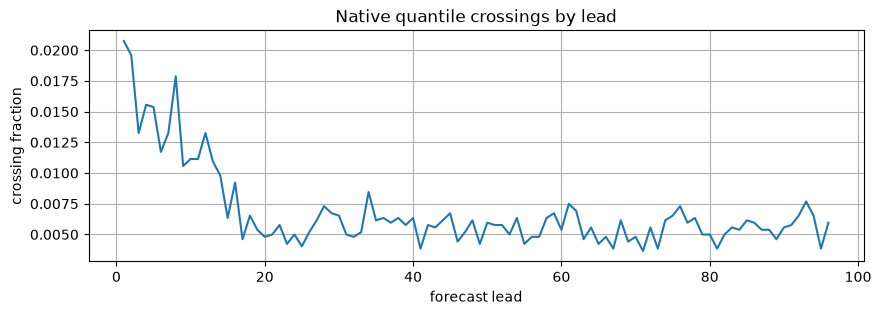

In [4]:
predictions = ds['quantile_prediction'].values
diagnostics = crossing_diagnostics(predictions)
print('crossing rate:', diagnostics.overall)
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(ds['lead'].values, diagnostics.by_lead)
ax.set(xlabel='forecast lead', ylabel='crossing fraction', title='Native quantile crossings by lead')
ax.grid(True)

complete_valid = np.isfinite(ds['pit_z'].values).all(axis=1)
print('complete valid origin-lead vectors:', complete_valid.sum(), '/', complete_valid.size)

## Dependence feature construction

M2 and M3 receive a deterministic feature vector for each entity and lead. It combines frozen Chronos patch embeddings with configured scalar descriptors of the fixed marginal grid and location. Standardization is fit on training origins only. The checkpoint stores its fitted `FeatureBuilder` state, so evaluation does not refit it on validation or test data.

In [5]:
features = config.features
builder = FeatureBuilder(
    output_patch_size=int(ds.attrs['output_patch_size']),
    shape_eps=features.shape_eps,
    standardize_scalar_features=features.standardize_scalar_features,
    use_forecast_embedding=features.use_forecast_embedding,
    use_quantile_shape=features.use_quantile_shape,
    use_median=features.use_median,
    use_log_spread=features.use_log_spread,
    use_within_patch_position=features.use_within_patch_position,
    use_location=features.use_location,
)
# Training code performs this same construction and fits the standardizer on train origins.
print(builder.configuration())
print('embedding shape:', ds['forecast_embedding'].shape)
print('quantile grid shape:', ds['quantile_prediction'].shape)

{'output_patch_size': 16, 'shape_eps': 1e-06, 'standardize_scalar_features': True, 'use_forecast_embedding': True, 'use_quantile_shape': True, 'use_median': True, 'use_log_spread': True, 'use_within_patch_position': True, 'use_location': True}
embedding shape: (347, 15, 6, 768)
quantile grid shape: (347, 15, 96, 21)
